In [ ]:
# Main idea is to

# 1. Generate Gaussian Pyramid for mask
# 2. Generate Laplassian Pyramids for images
# 3. Blend Pyramids
# 4. Reconstruct final image from blended pyramid

In [22]:
import cv2
import numpy as np

import matplotlib.pyplot as plt

In [16]:
# support functions

def generate_gaussian_pyramid(img, levels):
    """Helper function to generate Gaussian pyramid"""
    pyramid = [img.copy()]
    for i in range(levels - 1):
        img = cv2.pyrDown(img)
        pyramid.append(img)
    return pyramid

def generate_laplacian_pyramid(gaussian_pyramid):
    """Helper function to generate Laplacian pyramid"""
    laplacian_pyramid = []
    levels = len(gaussian_pyramid)

    for i in range(levels - 1):
        current = gaussian_pyramid[i]
        expanded = cv2.pyrUp(gaussian_pyramid[i + 1])

        # Resize expanded to match current size if needed
        if expanded.shape[:2] != current.shape[:2]:
            expanded = cv2.resize(expanded, (current.shape[1], current.shape[0]))

        laplacian = cv2.subtract(current, expanded)
        laplacian_pyramid.append(laplacian)

    laplacian_pyramid.append(gaussian_pyramid[-1])
    return laplacian_pyramid

In [17]:
# main blending function
def multiband_blend(src, dst, mask, levels=4):
    """
    Multi-band Blending using Laplacian Pyramids

    Parameters:
    src: Source image
    dst: Destination image
    mask: Binary mask
    levels: Number of pyramid levels
    """
    # Ensure images are float32
    src = src.astype(np.float32)
    dst = dst.astype(np.float32)
    mask = mask.astype(np.float32) / 255.0

    # Generate Gaussian pyramid for mask
    mask_pyramid = generate_gaussian_pyramid(mask, levels)

    # Generate Laplacian pyramids for source and destination
    src_pyramid = generate_laplacian_pyramid(generate_gaussian_pyramid(src, levels))
    dst_pyramid = generate_laplacian_pyramid(generate_gaussian_pyramid(dst, levels))

    # Blend pyramids
    blended_pyramid = []
    for i in range(levels):
        # Expand mask to 3 channels if needed
        if len(mask_pyramid[i].shape) == 2:
            mask_expanded = np.expand_dims(mask_pyramid[i], axis=-1)
        else:
            mask_expanded = mask_pyramid[i]

        # Blend at each level
        blended_level = src_pyramid[i] * mask_expanded + dst_pyramid[i] * (1 - mask_expanded)
        blended_pyramid.append(blended_level)

    # Reconstruct image from pyramid
    blended = blended_pyramid[-1]
    for i in range(levels - 2, -1, -1):
        expanded = cv2.pyrUp(blended)
        if expanded.shape[:2] != blended_pyramid[i].shape[:2]:
            expanded = cv2.resize(expanded,
                                (blended_pyramid[i].shape[1], blended_pyramid[i].shape[0]))
        blended = cv2.add(expanded, blended_pyramid[i])

    return np.clip(blended, 0, 255).astype(np.uint8)

In [ ]:
# load and prepare data

!gdown https://drive.google.com/uc?id=1teMMV7lxXotlzYqnt-a8-zn6nVYsYPFZ&export=download
!unzip frames.zip

Downloading...
From: https://drive.google.com/uc?id=1teMMV7lxXotlzYqnt-a8-zn6nVYsYPFZ
To: /content/frames.zip
100% 1.00M/1.00M [00:00<00:00, 111MB/s]
Archive:  frames.zip
replace __MACOSX/._frames? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [32]:
src = cv2.imread('frames/imgs/110020220079_01.png')
dst = cv2.imread('frames/bg/bg_1.jpg')
mask = cv2.imread('frames/masks/110020220079_01.png', 0)  # Read mask as grayscale

In [33]:
# Ensure all images have the same size
dst = cv2.resize(dst, (src.shape[1], src.shape[0]))
mask = cv2.resize(mask, (src.shape[1], src.shape[0]))

In [34]:
multiband_result = multiband_blend(src, dst, mask)

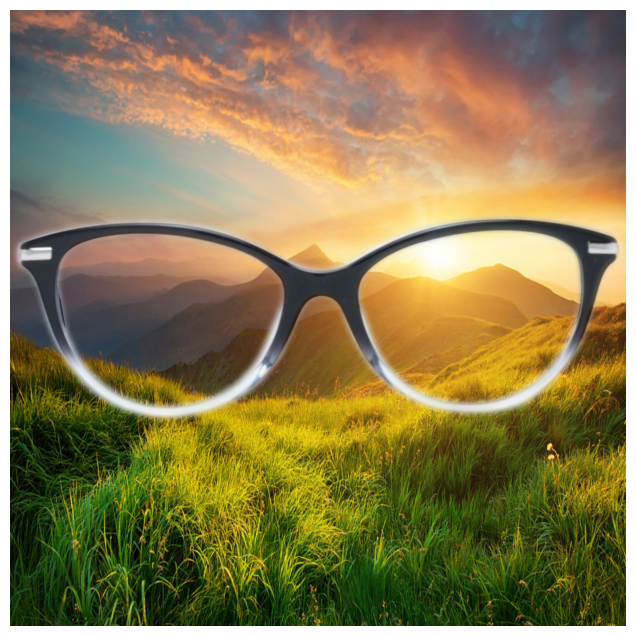

In [35]:
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(multiband_result, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for display
plt.axis('off')  # no axis labels
plt.show()